# Function 1- Bayesian Optimization

## Function 1 Description

Detect likely contamination sources in a two-dimensional area, such as a radiation field, where only proximity yields a non-zero reading. The system uses Bayesian optimisation to tune detection parameters and reliably identify both strong and weak sources.

## Starting point
*  Input - 2D array (10,2)
*  Output - 1D array (10,)
*  Optimisation goal - Maximise

## Bayesian Optimization (BO) workflow on capstone project

*   BO with Upper Control Bound (UCB)
*   Visuals of progress and surrogate intuition
*   Final training with the optimized hyperparameters

### Import Libraries

In [1]:
import io, math, pathlib, numpy as np, pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from scipy.stats import norm

import warnings
warnings.filterwarnings("ignore")

#### Setup Parameters

In [2]:
plt.rcParams['figure.figsize'] = (5,3)
plt.rcParams['figure.dpi'] = 140
plt.rcParams['axes.grid'] = True

### Assign Data to variables X and y

In [3]:
import numpy as np, pandas as pd, pathlib

# To load a .npy file into a pandas DataFrame:
# 1. Load the .npy file using numpy.load()
# 2. Convert the resulting numpy array to a pandas DataFrame using pd.DataFrame()

# Attempting to load from '/content/data/' as is common in Colab, or from a 'data/' subfolder
try:
    # Try loading from /content/data/
    X_array = np.load('/content/data/initial_inputs1.npy')
    y_array = np.load('/content/data/initial_outputs1.npy')
    print("Files loaded successfully from /content/data/")

except FileNotFoundError:
    try:
        # If not in /content/data/, try loading from a 'data/' subfolder in the current directory
        X_array = np.load('data/initial_inputs1.npy')
        y_array = np.load('data/initial_outputs1.npy')
        print("Files loaded successfully from data/ subfolder.")
    except FileNotFoundError:
       print("Error: One or both .npy files not found at /content/data/ or data/.")
       print("Please ensure they are in the correct path.")
       print("Current working directory files: ", list(pathlib.Path().absolute().glob('*.npy')))
       print("Files in /content/data/: ", list(pathlib.Path('/content/data/').absolute().glob('*.npy')))

       # Create dummy data if files are not found to allow notebook execution to proceed
       X_array = np.random.rand(10, 2) # Example: 10 samples, 8 features
       y_array = np.random.rand(10,)  # Example: 10 samples, 1 output
       print("\nUsing dummy data for X and y to continue.")

# Convert to DataFrame if needed, or use as NumPy arrays directly for your model
X_df = pd.DataFrame(X_array)
y_df = pd.DataFrame(y_array, columns=['target_output'])

print("Shape of X (NumPy array):", X_array.shape)
print("Shape of y (NumPy array):", y_array.shape)
print("\nFirst 5 rows of X (DataFrame):")
display(X_df.head())
print("\nFirst 5 rows of y (DataFrame):")
display(y_df.head())

# Assign X and y for subsequent steps (as NumPy arrays, based on original notebook context)
X = X_array
y = y_array


Files loaded successfully from /content/data/
Shape of X (NumPy array): (10, 2)
Shape of y (NumPy array): (10,)

First 5 rows of X (DataFrame):


,0,1
0,0.319404,0.762959
1,0.574329,0.879898
2,0.731024,0.733000
3,0.840353,0.264732
4,0.650114,0.681526



First 5 rows of y (DataFrame):


,target_output
0,1.322677e-79
1,1.033078e-46
2,7.710875e-16
3,3.341771e-124
4,-3.606063e-03


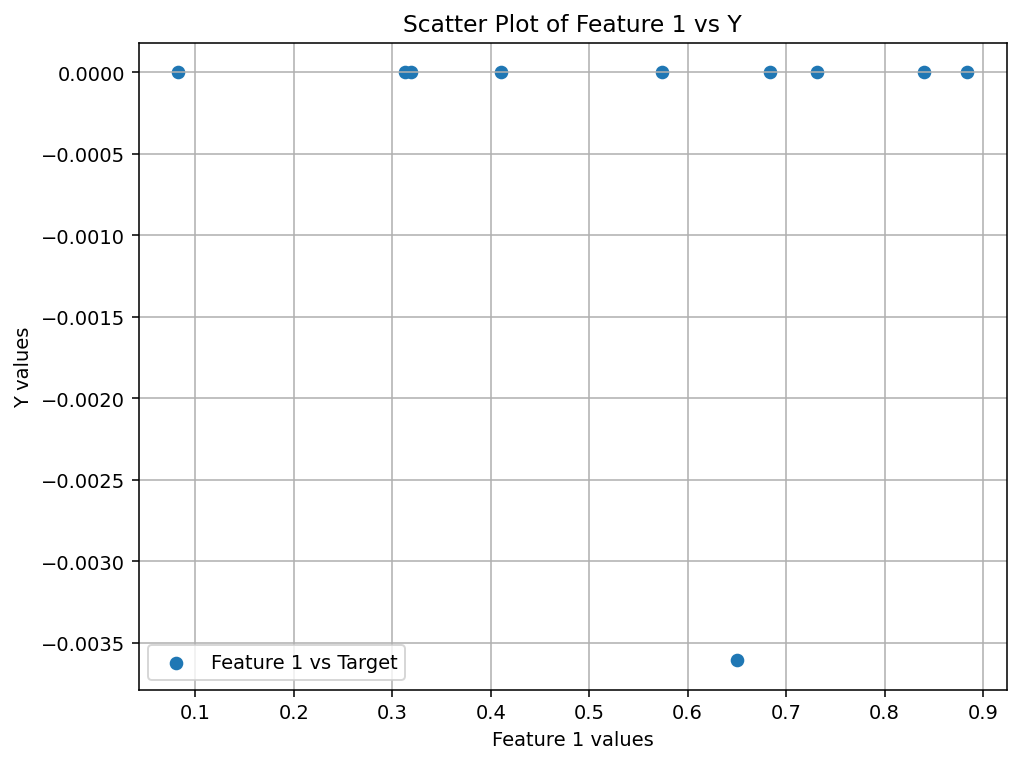

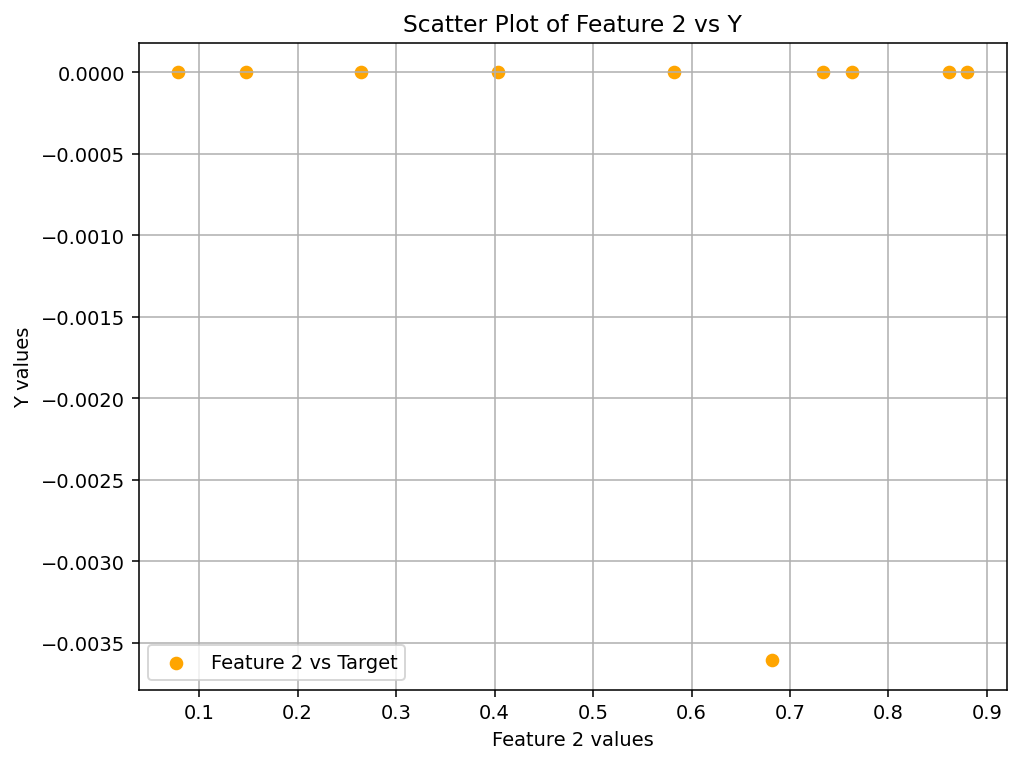

In [4]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], y, label='Feature 1 vs Target')
plt.xlabel('Feature 1 values')
plt.ylabel('Y values')
plt.title('Scatter Plot of Feature 1 vs Y')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 1], y, label='Feature 2 vs Target', color='orange')
plt.xlabel('Feature 2 values')
plt.ylabel('Y values')
plt.title('Scatter Plot of Feature 2 vs Y')
plt.legend()
plt.grid(True)
plt.show()

To add new data points, you'll need to create new NumPy arrays for the input features (`new_X_points`) and target outputs (`new_y_points`). Ensure that the new points have the same number of features as your existing `X` array.

Then, use `np.vstack` to vertically stack the new `X` points onto the existing `X` array, and `np.concatenate` to combine the new `y` points with the existing `y` array.

In [5]:
import numpy as np

# Assume X and y are already defined from previous cells
# Example: X_array.shape = (10, 2), y_array.shape = (10,)

# Create new data points
# Make sure new_X_points has the same number of columns as X
# and new_y_points has compatible dimensions with y

# For X (features), assume 2 features per data point
# Let's add 3 new data points
new_X_points = np.array([
    [0.100000, 0.900000], # week 1 capstone submission - scatter plots, eye ball
    [0.018054, 0.638258], # week 2 capstone submission - UCB KAPPA = 40.0
    [0.316430, 0.242115], # week 3 capstone submission - UCB KAPPA = 40.0
    [0.698669, 0.285582], # week 4 capstone submission - UCB KAPPA = 200.0
    [0.500000, 0.500000], # week 5 capstone submission - no UCB, scatter plot, unexplored region
    [0.849509, 0.014190], # week 6 capstone submission - UCB KAPPA= 0.1
    [0.645000, 0.675000], # week 7 capstone submission - no UCB, scatter plot, unexplored region
    [0.655000, 0.686000]  # week 8 capstone submission - no UCB, scatter plot, unexplored region, other side of best point so far
    #[0.79964398 0.49863492] # week 9 capstone submission - UCB, KAPPA 100.0, N_ITER = 20.0 and added max_depth and subsample to search space
])

# For y (target), assume a single output value per data point
new_y_points = np.array([
    1.0740340011599467e-231,# week 1 capstone processed output
    1.205791869281642e-146, # week 2 capstone processed output
   -2.9676727318230984e-31, # week 3 capstone processed output
    3.637515974272763e-68,  # week 4 capstone processed output
    2.6752879910742468e-9,  # week 5 capstone processed output
    3.461881179454123e-244, # week 6 capstone processed output
    -0.009200473890295543,  # week 7 capstone processed output
    -0.0010804154570424737  # week 8 ccapstone processed output
     #                      week 9 capstone processed output
])

# Verify shapes before adding
print(f"Original X shape: {X.shape}")
print(f"Original y shape: {y.shape}")
print(f"New X points shape: {new_X_points.shape}")
print(f"New y points shape: {new_y_points.shape}")

# Add the new data points
X = np.vstack([X, new_X_points])
y = np.concatenate([y, new_y_points])

print(f"\nUpdated X shape: {X.shape}")
print(f"Updated y shape: {y.shape}")

# Display the last few rows to see the added data
print("\nLast 5 rows of updated X:")
display(pd.DataFrame(X).tail())
print("\nLast 5 rows of updated y:")
display(pd.DataFrame(y, columns=['target_output']).tail())


Original X shape: (10, 2)
Original y shape: (10,)
New X points shape: (8, 2)
New y points shape: (8,)

Updated X shape: (18, 2)
Updated y shape: (18,)

Last 5 rows of updated X:


,0,1
13,0.698669,0.285582
14,0.500000,0.500000
15,0.849509,0.014190
16,0.645000,0.675000
17,0.655000,0.686000



Last 5 rows of updated y:


,target_output
13,3.637516e-68
14,2.675288e-09
15,3.461881e-244
16,-9.200474e-03
17,-1.080415e-03


Minimum y value: -9.2004738903e-03
Maximum y value: 2.6752879911e-09


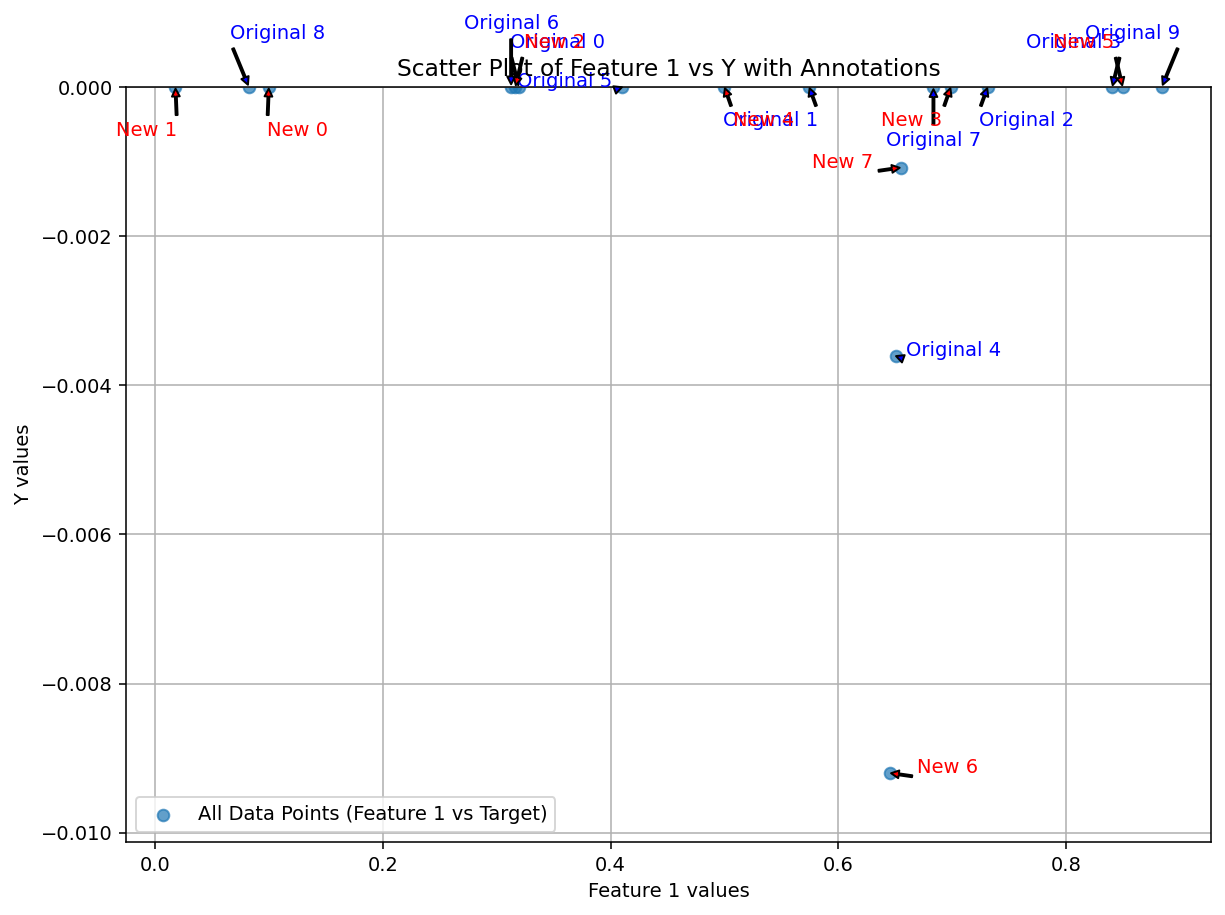

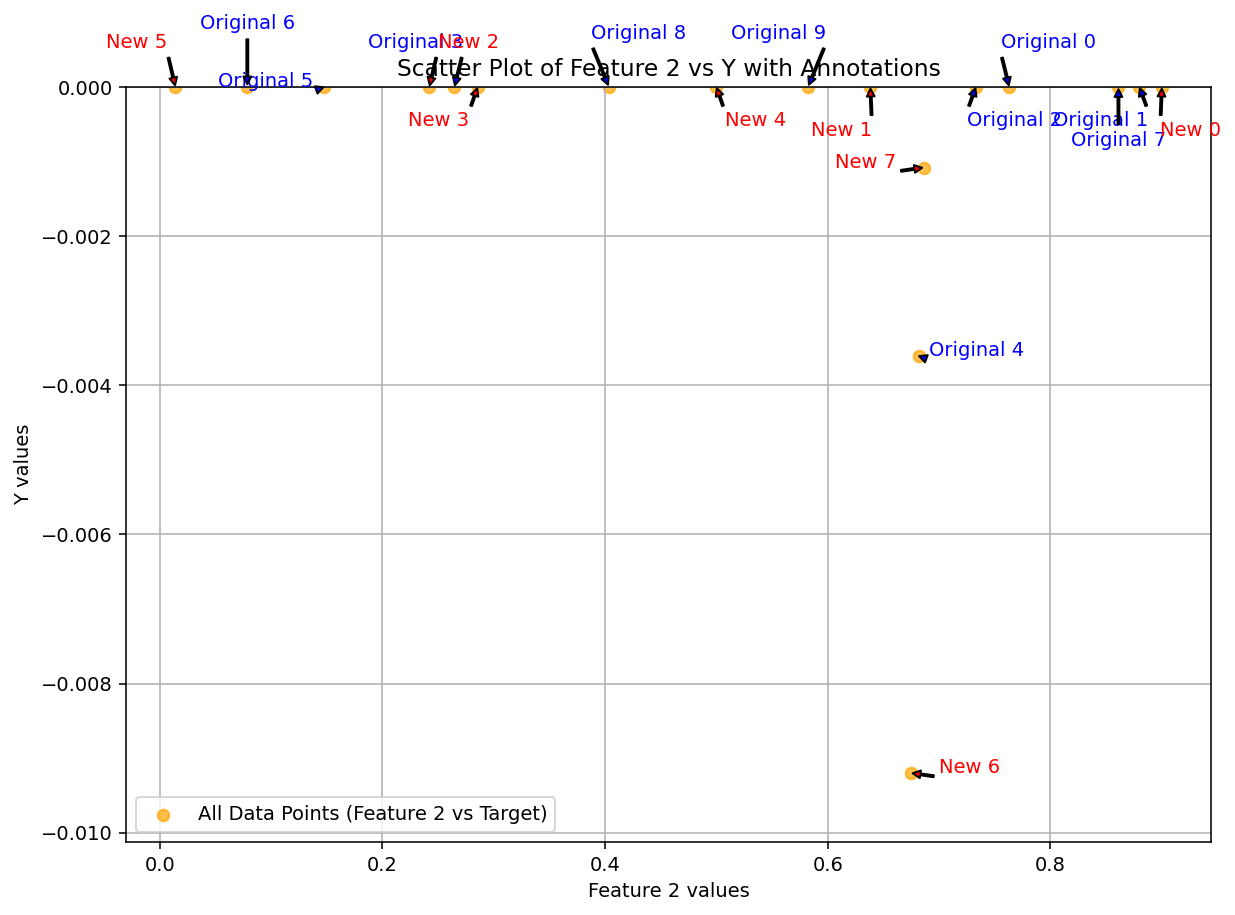

In [6]:
print(f"Minimum y value: {np.min(y):.10e}")
print(f"Maximum y value: {np.max(y):.10e}")

plt.figure(figsize=(10, 7)) # Increased figure size for better readability
plt.scatter(X[:, 0], y, label='All Data Points (Feature 1 vs Target)', alpha=0.7)
plt.xlabel('Feature 1 values')
plt.ylabel('Y values')
plt.title('Scatter Plot of Feature 1 vs Y with Annotations')
plt.legend()
plt.grid(True)

# Set y-axis limits to clearly show negative values
y_min = np.min(y)
y_max = np.max(y)
plt.ylim(y_min - abs(y_min * 0.1), y_max + abs(y_max * 0.1) if y_max > 0 else 1e-8) # Add a small buffer

# Define a list of larger offsets to cycle through for better annotation placement
offsets = [
    (20, 20), (-20, -20), (20, -20), (-20, 20),
    (30, 0), (-30, 0), (0, 30), (0, -30),
    (15, 25), (-15, 25), (15, -25), (-15, -25)
]

# Annotate each point for Feature 1
num_original_points = X_array.shape[0]
for i in range(X.shape[0]):
    offset = offsets[i % len(offsets)] # Cycle through offsets
    if i < num_original_points:
        label = f'Original {i}'
        color = 'blue'
    else:
        label = f'New {i - num_original_points}'
        color = 'red' # Use a different color for new points to distinguish visually
    plt.annotate(
        label,
        (X[i, 0], y[i]),
        textcoords="offset points",
        xytext=offset,
        ha='center',
        color=color,
        arrowprops=dict(facecolor=color, shrink=0.05, width=1, headwidth=4, headlength=4)
    )
plt.show()

plt.figure(figsize=(10, 7)) # Increased figure size for better readability
plt.scatter(X[:, 1], y, label='All Data Points (Feature 2 vs Target)', color='orange', alpha=0.7)
plt.xlabel('Feature 2 values')
plt.ylabel('Y values')
plt.title('Scatter Plot of Feature 2 vs Y with Annotations')
plt.legend()
plt.grid(True)

# Set y-axis limits for the second plot as well
plt.ylim(y_min - abs(y_min * 0.1), y_max + abs(y_max * 0.1) if y_max > 0 else 1e-8) # Add a small buffer

# Annotate each point for Feature 2
for i in range(X.shape[0]):
    offset = offsets[i % len(offsets)] # Cycle through offsets
    if i < num_original_points:
        label = f'Original {i}'
        color = 'blue'
    else:
        label = f'New {i - num_original_points}'
        color = 'red' # Use a different color for new points to distinguish visually
    plt.annotate(
        label,
        (X[i, 1], y[i]),
        textcoords="offset points",
        xytext=offset,
        ha='center',
        color=color,
        arrowprops=dict(facecolor=color, shrink=0.05, width=1, headwidth=4, headlength=4)
    )
plt.show()

In [7]:
# Identify the top 3 y-readings with the largest absolute difference from zero
abs_y = np.abs(y)
sorted_abs_y_indices = np.argsort(abs_y)[::-1] # Sort in descending order of absolute value

top_3_abs_y_indices = sorted_abs_y_indices[:3]

print("Top 3 Y values with the largest absolute difference from zero:")
for i, original_index in enumerate(top_3_abs_y_indices):
    y_value = y[original_index]
    abs_y_value = abs_y[original_index]
    x_values = X[original_index]
    print(f"\n  Rank {i+1}:")
    print(f"    Original Index: {original_index}")
    print(f"    Y value: {y_value:.10e}")
    print(f"    Absolute Y value: {abs_y_value:.10e}")
    print(f"    Corresponding X input values: {x_values}")

Top 3 Y values with the largest absolute difference from zero:

  Rank 1:
    Original Index: 16
    Y value: -9.2004738903e-03
    Absolute Y value: 9.2004738903e-03
    Corresponding X input values: [0.645 0.675]

  Rank 2:
    Original Index: 4
    Y value: -3.6060626444e-03
    Absolute Y value: 3.6060626444e-03
    Corresponding X input values: [0.65011406 0.68152635]

  Rank 3:
    Original Index: 17
    Y value: -1.0804154570e-03
    Absolute Y value: 1.0804154570e-03
    Corresponding X input values: [0.655 0.686]


### Objective and baseline
Baseline model provides us the RMSE benchmark as a starting point

In [8]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor #GradientBoostingRegressor

cv = KFold(n_splits=5, shuffle=True, random_state=42)
def rmse_cv(model):
    scores = cross_val_score(model, X, y, cv=cv, scoring="neg_mean_squared_error")
    return float(np.sqrt(-scores).mean())

baseline = GradientBoostingRegressor(random_state=42)
baseline_rmse = rmse_cv(baseline)
print(f"Baseline GBR RMSE (5-fold): {baseline_rmse:.3f}")

Baseline GBR RMSE (5-fold): 0.001


### Search Space and Helper Functions

In [9]:
# Search space for 2D input
space = {
    "n_estimators": (50, 400),
    "learning_rate": (0.01, 0.30),
    "max_depth": (1, 10),  # Added max_depth to search space (integer)
    "subsample": (0.5, 1.0) # Added subsample to search space (float)
}
hp = list(space.keys()); d = len(hp) # d will now be 4

# Converts normalized values in [0,1] into actual hyperparameter values (and rounds when needed, e.g., integers like n_estimators)
def to_params(x01):
    out = {}
    for i, name in enumerate(hp):
        lo, hi = space[name]
        v = lo + x01[i]*(hi-lo)
        if name in ["n_estimators", "max_depth"]: # n_estimators and max_depth are integers
            v = int(round(v))
        out[name] = float(v) # Ensure all are stored as floats initially, but max_depth will be cast to int by GBR later
    return out

# Builds a GradientBoostingRegressor with given params and returns its 5-fold CV RMSE. So BO minimizes error (RMSE)
def objective(params):
    model = GradientBoostingRegressor(
        n_estimators=int(params["n_estimators"]),
        learning_rate=float(params["learning_rate"]),
        max_depth=int(params["max_depth"]), # Use max_depth from params
        subsample=float(params["subsample"]), # Use subsample from params
        random_state=42
    )
    return rmse_cv(model)

# The normal_pdf and normal_cdf functions remain unchanged
scipy_OK = True # Define scipy_OK here to prevent NameError
def normal_pdf(z):
    if scipy_OK:
        return norm.pdf(z)
    return (1.0/np.sqrt(2*np.pi))*np.exp(-0.5*z**2)

### Step by Step BO with UCB decomposition

#### Import Libraries

In [10]:
from dataclasses import dataclass
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
import numpy as np, pandas as pd, matplotlib.pyplot as plt

#### Dataclass to store all details of each step in the optimization

In [11]:
@dataclass
class StepLog:
    it: int; params: dict; rmse: float; mu: float; sigma: float; ei: float
    exploit_contrib: float; explore_contrib: float; tag: str; best_rmse: float

**Control the knobs for the BO run**
* N_INIT = number of warm-up random trials before BO starts learning
* N_ITER = number of BO-guided iterations
* KAPPA = exploration bias parameter for Upper Confidence Bound (UCB)
* N_CAND = how many candidate points to evaluate at each step
* rng = random generator for reproducibility



In [63]:
N_INIT, N_ITER, KAPPA, N_CAND = 8, 20.0, 100, 2000 # Set KAPPA to 100 for exploration and N_INTER to 20.0 for Week 9
rng = np.random.RandomState(123)

#### Warm-up trials - BO needs some initial data to train the surrogate

In [64]:
X_trials = rng.rand(N_INIT, d)
y_trials = np.array([objective(to_params(x)) for x in X_trials])
best_rmse = float(np.min(y_trials))

#### Initialize logging with warm-up trials
Will be tagged as Warm-up

In [65]:
logs = []
cum_best = np.minimum.accumulate(y_trials)
for i in range(N_INIT):
    logs.append(StepLog(i-(N_INIT-1), to_params(X_trials[i]), float(y_trials[i]), float('nan'), float('nan'),
                        float('nan'), float('nan'), float('nan'), "Warm-up", float(cum_best[i])))

#### Define surrogate (Gaussian Process)
This is the GP surrogate model that predicts mean (mu) and uncertainty (sigma)

In [66]:
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=np.ones(d), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-9, 1e-2))
gpr = GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=42, n_restarts_optimizer=3)

trace = [best_rmse]

#### Bayesian Optimization loop
For Each iteration:
1. Fit surrogate
2. Predict many candidates
3. Compute UCB
4. Pick best candidate
5. Classify step as Exploration/Exploitation
6. Evaluate real objective
7. Update logs and best_rmse

This code block implements the main Bayesian Optimization loop. It iteratively searches for the best hyperparameters for the Gradient Boosting Regressor model, using the Upper Confidence Bound (UCB) acquisition function.

Here's a breakdown of what happens in each iteration:

Surrogate Model Fitting: gpr.fit(X_trials, y_trials) - The Gaussian Process Regressor (gpr), which acts as a surrogate model, is trained on all the hyperparameter combinations (X_trials) and their corresponding RMSE values (y_trials) observed up to that point. This updates the model's understanding of the objective function.

Candidate Generation and Prediction: CAND = rng.rand(N_CAND, d) and mu, std = gpr.predict(CAND, return_std=True) - A large number of random candidate hyperparameter sets (CAND) are generated. The surrogate model then predicts the expected RMSE (mu) and the uncertainty (std) for each of these candidates.

UCB Calculation: ucb = mu + KAPPA * std - The Upper Confidence Bound is calculated for each candidate. UCB balances exploitation (favoring hyperparameters that are predicted to give a low RMSE, represented by mu) and exploration (favoring hyperparameters where the model has high uncertainty, represented by std, scaled by KAPPA). The goal is to find the candidate that maximizes this UCB value.

Next Point Selection: idx = int(np.argmax(ucb)); x_next = CAND[idx] - The candidate hyperparameter set with the highest UCB score is chosen as the next point to be evaluated in the actual objective function.

Logging Surrogate Predictions: mu_star, sig_star = float(mu[idx]), float(std[idx]) - The predicted mean and standard deviation for the chosen point are stored.

Determining Exploration/Exploitation Contribution: The code approximates the contribution of the mean (mu) and uncertainty (KAPPA * std) to the UCB score to classify whether the chosen point was primarily for 'Exploration' or 'Exploitation'.

Objective Evaluation: params_next = to_params(x_next); y_next = objective(params_next) - The actual Gradient Boosting Regressor model is trained and evaluated using the selected hyperparameters (params_next), yielding a real RMSE value (y_next). This is typically the most computationally expensive step.

Update Trial Data: The newly evaluated hyperparameter set (x_next) and its RMSE (y_next) are added to the X_trials and y_trials datasets, which will be used to train the surrogate model in the next iteration.

Track Best RMSE: if y_next < best_rmse: best_rmse = float(y_next) - The best_rmse found so far is updated if the current y_next is lower.

Log Step Details: All relevant information for the current iteration, including the chosen parameters, actual RMSE, and surrogate predictions, is logged into the logs list.

This iterative process allows the Bayesian Optimization algorithm to efficiently explore the hyperparameter space and converge towards optimal settings, balancing the search for better values with reducing uncertainty about the objective function.

In [67]:
for it in range(1, int(N_ITER)+1):
    # Fit surrogate on all past trials
    gpr.fit(X_trials, y_trials)

    # Generate candidate points and predict mean/uncertainty
    CAND = rng.rand(N_CAND, d)
    mu, std = gpr.predict(CAND, return_std=True)

    # Compute Upper Confidence Bound (UCB) for each candidate
    # UCB = mu + KAPPA * std. We want to maximize this.
    ucb = mu + KAPPA * std

    # Pick the candidate with maximum UCB
    idx = int(np.argmax(ucb)); x_next = CAND[idx]
    mu_star, sig_star = float(mu[idx]), float(std[idx])
    # EI-related values are not directly applicable to UCB, setting to NaN or 0
    ei_star = float('nan')
    imp_star = float('nan')
    z_star = float('nan')

    # UCB is inherently a balance of exploitation (mu) and exploration (std*KAPPA)
    # We can approximate contribution for logging, or simply tag as 'UCB'
    contrib_exploit = float(mu[idx]) # Exploitation is driven by the mean prediction
    contrib_explore = float(KAPPA * std[idx]) # Exploration is driven by uncertainty weighted by KAPPA
    tag = "UCB (Exploration)" if KAPPA * std[idx] > abs(mu[idx]) else "UCB (Exploitation)"

    # Evaluate true objective at chosen point
    params_next = to_params(x_next); y_next = objective(params_next)
    X_trials = np.vstack([X_trials, x_next[None,:]])
    y_trials = np.concatenate([y_trials, [y_next]])
    if y_next < best_rmse: best_rmse = float(y_next)
    trace.append(best_rmse)

    # Log the step
    logs.append(StepLog(it, params_next, float(y_next), mu_star, sig_star, ei_star,
                        contrib_exploit, contrib_explore, tag, best_rmse))


#### Log final step log DataFrame

In [68]:
log_df = pd.DataFrame([{
    "iter": s.it, "tag": s.tag, "rmse": s.rmse, "best_rmse_so_far": s.best_rmse,
    "mu": s.mu, "sigma": s.sigma, "ei": s.ei,
    "exploit_contrib": s.exploit_contrib, "explore_contrib": s.explore_contrib,
    **{k: s.params[k] for k in s.params}
} for s in logs])
log_df.head(20)

,iter,tag,rmse,best_rmse_so_far,mu,sigma,ei,exploit_contrib,explore_contrib,n_estimators,learning_rate,max_depth,subsample
0,-7,Warm-up,0.001749,0.001749,NaN,NaN,NaN,NaN,NaN,294.0,0.092980,3.0,0.775657
1,-6,Warm-up,0.001571,0.001571,NaN,NaN,NaN,NaN,NaN,302.0,0.132701,10.0,0.842415
2,-5,Warm-up,0.001480,0.001480,NaN,NaN,NaN,NaN,NaN,218.0,0.123714,4.0,0.864525
3,-4,Warm-up,0.001415,0.001415,NaN,NaN,NaN,NaN,NaN,204.0,0.027307,5.0,0.868998
4,-3,Warm-up,0.001769,0.001415,NaN,NaN,NaN,NaN,NaN,114.0,0.060881,6.0,0.765914
5,-2,Warm-up,0.001624,0.001415,NaN,NaN,NaN,NaN,NaN,272.0,0.256335,8.0,0.805512
6,-1,Warm-up,0.002002,0.001415,NaN,NaN,NaN,NaN,NaN,303.0,0.103658,4.0,0.614132
7,0,Warm-up,0.002049,0.001415,NaN,NaN,NaN,NaN,NaN,153.0,0.192983,2.0,0.716851
8,1,UCB (Exploration),0.002010,0.001415,0.001791,0.000242,NaN,0.001791,0.024200,355.0,0.290323,1.0,0.501215
9,2,UCB (Exploration),0.002584,0.001415,0.001892,0.000202,NaN,0.001892,0.020167,123.0,0.296030,9.0,0.507190


### Visuals

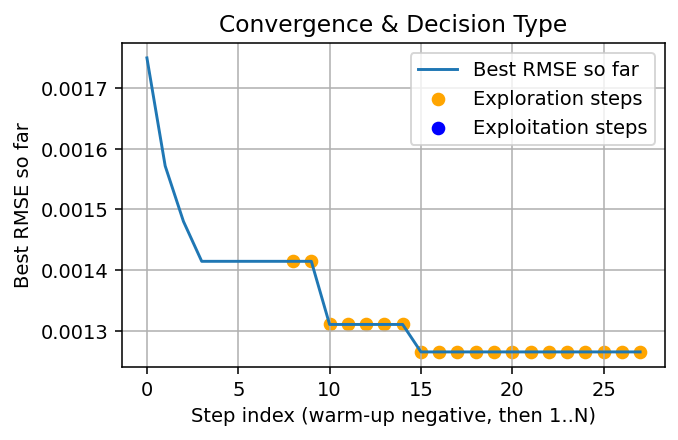

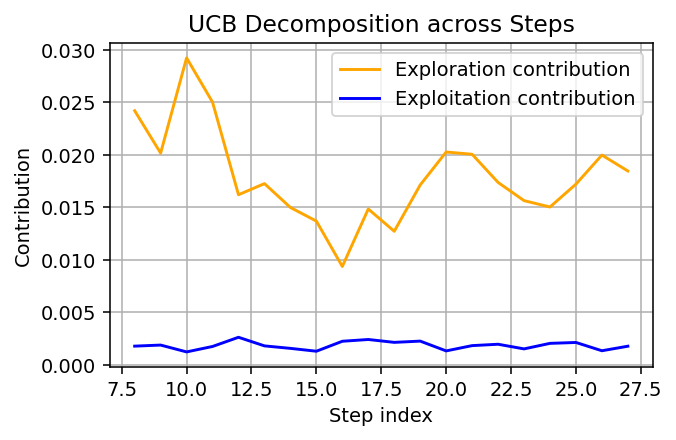

In [70]:
mask_explr = log_df["tag"] == "UCB (Exploration)"; mask_explt = log_df["tag"] == "UCB (Exploitation)"

plt.figure()
plt.plot(log_df["best_rmse_so_far"], label="Best RMSE so far")
plt.scatter(log_df.index[mask_explr], log_df.loc[mask_explr, "best_rmse_so_far"], label="Exploration steps", color="orange")
plt.scatter(log_df.index[mask_explt], log_df.loc[mask_explt, "best_rmse_so_far"], label="Exploitation steps", color="blue")
plt.xlabel("Step index (warm-up negative, then 1..N)"); plt.ylabel("Best RMSE so far")
plt.title("Convergence & Decision Type"); plt.legend(); plt.show()

plt.figure()
plt.plot(log_df["explore_contrib"], label="Exploration contribution",color="orange")
plt.plot(log_df["exploit_contrib"], label="Exploitation contribution", color="blue")
plt.xlabel("Step index"); plt.ylabel("Contribution")
plt.title("UCB Decomposition across Steps"); plt.legend(); plt.show()

In [71]:
best_row_overall = log_df.loc[log_df['best_rmse_so_far'].idxmin()]
print(f"Baseline GBR RMSE: {baseline_rmse:.3f}")
print(f"Best n_estimators: {int(best_row_overall['n_estimators'])}")
print(f"Best learning_rate: {best_row_overall['learning_rate']:.5f}")
print(f"Achieved RMSE: {best_row_overall['best_rmse_so_far']:.5f}")

Baseline GBR RMSE: 0.001
Best n_estimators: 386
Best learning_rate: 0.16182
Achieved RMSE: 0.00127


#### Surrogate slice: initial vs final (learning_rate)
Fits a Gaussian Process surrogate on the current trials (X_used, y_used)

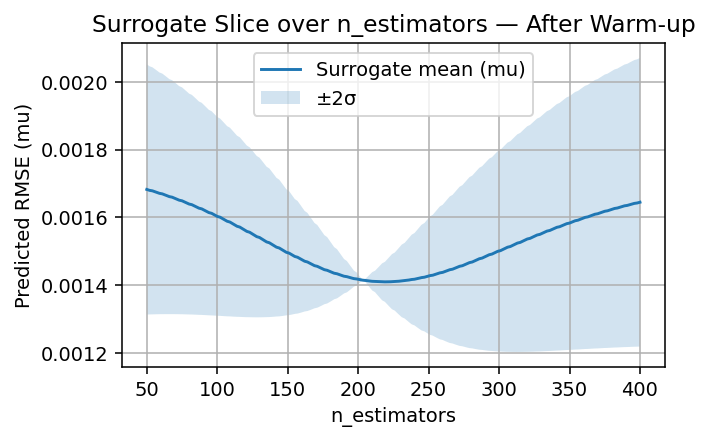

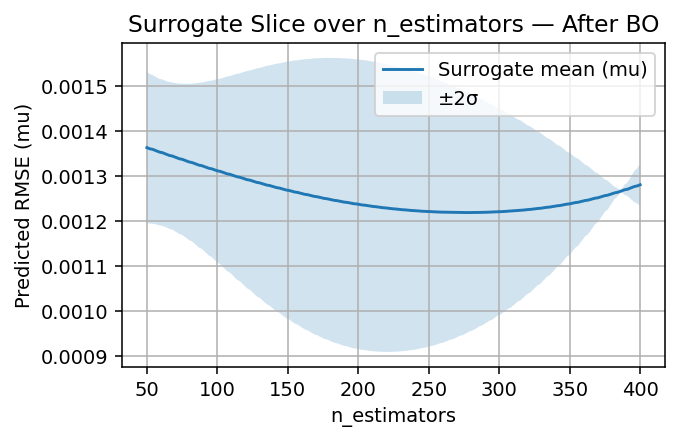

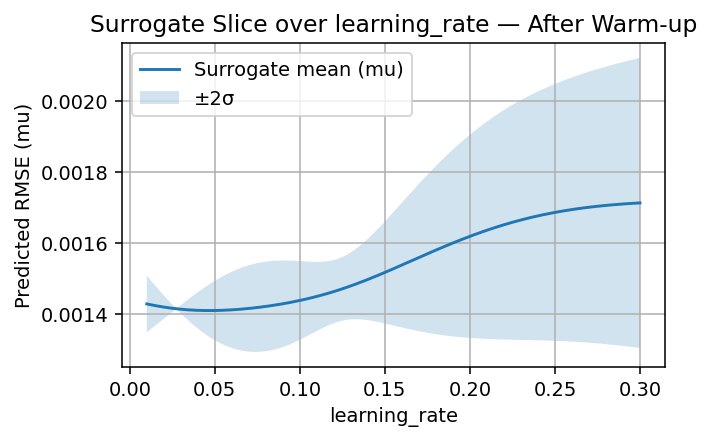

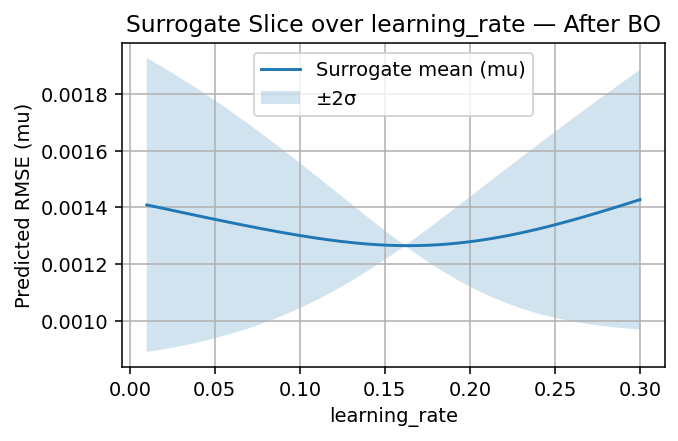

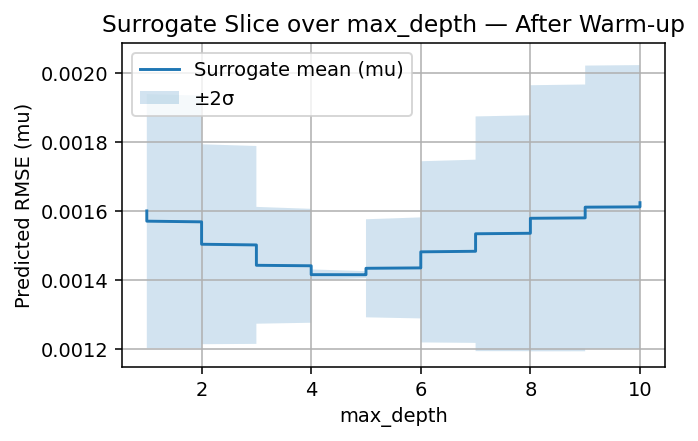

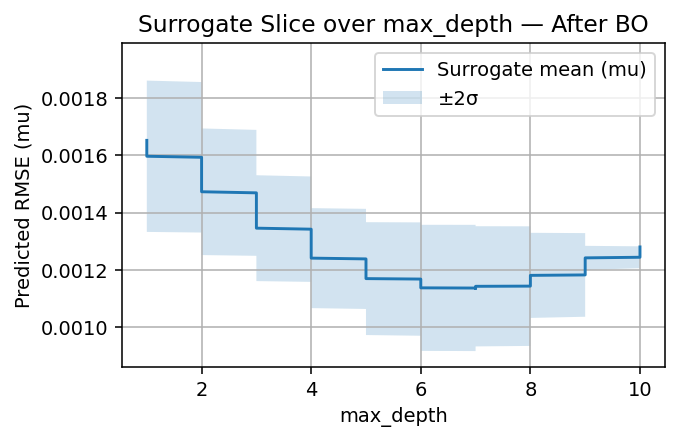

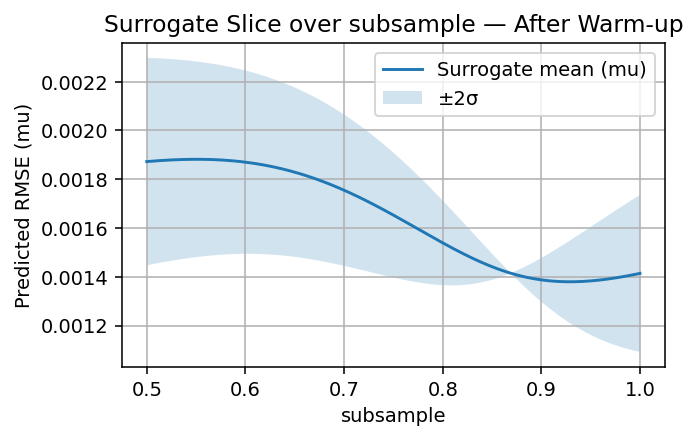

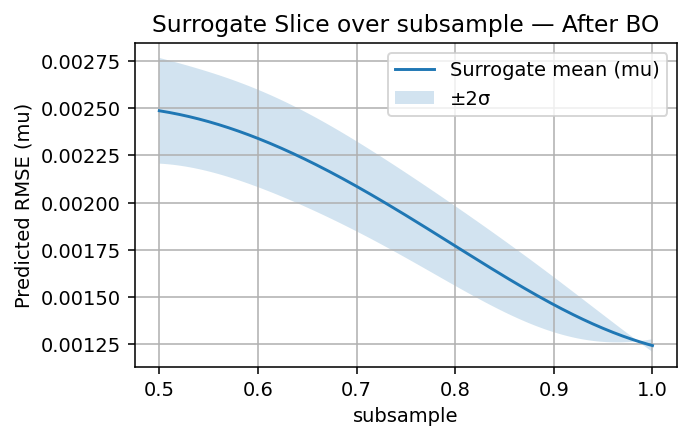

In [72]:
def surrogate_slice_plot(X_used, y_used, hyperparam_name, title_suffix):
    gp = GaussianProcessRegressor(kernel=C(1.0)*Matern(nu=2.5)+WhiteKernel(1e-6), normalize_y=True, random_state=0)
    gp.fit(X_used, y_used)

    # Best trial so far
    best_idx = np.argmin(y_used); anchor = X_used[best_idx].copy()

    # Use the hyperparam_name to get the correct index and bounds
    j = list(space.keys()).index(hyperparam_name)
    lo, hi = space[hyperparam_name]

    xs = np.linspace(0,1,300); grid = np.tile(anchor, (len(xs),1)); grid[:, j] = xs
    mu, std = gp.predict(grid, return_std=True)

    # Calculate parameter values and round if it's an integer hyperparameter
    param_vals = lo + xs*(hi-lo)
    if hyperparam_name in ["n_estimators", "max_depth"]:
        param_vals = np.round(param_vals).astype(int)

    plt.figure()
    plt.plot(param_vals, mu, label="Surrogate mean (mu)")
    plt.fill_between(param_vals, mu-2*std, mu+2*std, alpha=0.2, label="±2σ")
    plt.xlabel(hyperparam_name); plt.ylabel("Predicted RMSE (mu)")
    plt.title(f"Surrogate Slice over {hyperparam_name} — {title_suffix}")
    plt.legend(); plt.show()

X_warm = np.array([r for r in globals()['X_trials'][:N_INIT]])
y_warm = np.array([objective(to_params(x)) for x in X_warm])

for hp_name in space.keys():
    surrogate_slice_plot(X_warm, y_warm, hp_name, "After Warm-up")
    surrogate_slice_plot(globals()['X_trials'], globals()['y_trials'], hp_name, "After BO")

**Weekly strategy**

* **Week 4**: using a KAPPA of 200, the next candidate offered was [0.698669, 0.285582].
* **Week 5** : looking at the scatter plots after adding 4 new data points, it seems there is one maximum. However there is a grid in the 0.5 range in both features which is worth exploring in case there is a another maximum which might be the global maximum. So submission will be: [0.500000-0.500000] without use of BO.
* **Week 6** : try a candidate submission from an exploitative strategy using a KAPPA of 0.1. No real improvement seen in learning.
* **Week 7**, revert back to scatter plots and submit inputs around the X-input values which so far has generated the highest nonzero reading (around orginal data point 4 [0.65011406 0.68152635] with a y output of -3.60606264e-003). Submitted week 7 submission will be [0.645, 0.675].


---
* **Week 8** submission will be the other side [0.655, 0.686]
  - **Summary after adding week 8 input/output : Top 3 Y values with the largest absolute difference from zero:**

  - Rank 1:
    Original Index: 16
    Y value: -9.2004738903e-03
    Absolute Y value: 9.2004738903e-03
    Corresponding X input values: [0.645 0.675]

  - Rank 2:
    Original Index: 4
    Y value: -3.6060626444e-03
    Absolute Y value: 3.6060626444e-03
    Corresponding X input values: [0.65011406 0.68152635]

  - Rank 3:
    Original Index: 17
    Y value: -1.0804154570e-03
    Absolute Y value: 1.0804154570e-03
    Corresponding X input values: [0.655 0.686]



---
* **Week 9** submission was focusing on hyperparameter tuning as no improvement seen in week 5 in surrogate slice learning rate plots since week 5,although an improvement in optimised RMSE seen with week 8 results but still greater than the baseline rmse of 0.001. Changed the search space to include ranges for hyperparameters max_depth and subsample which were previously fixed, set KAPPA to 100 (for explorationn) and N_ITER to 20.0 and re-ran. Much better rmse results! (surrogate slice plots expanded to cover all four hyperparameters)
  - Suggested next X data point (2D coordinates): [0.79964398 0.49863492]
  - Predicted Y at this point (mean): -7.71497e-04
  - Predicted uncertainty (std) at this point: 2.21241e-03
  - UCB value at this point: 2.20470e-01



### Final Model (on best parameters)

Baseline GBR RMSE: 0.001
Optimized hyperparameters (from BO with UCB):
  n_estimators: 386
  learning_rate: 0.1618199651578786
  max_depth: 10
  subsample: 0.9852906265129997
Achieved RMSE (UCB): 0.00127

Final (BO with UCB) 5-fold RMSE: 0.001


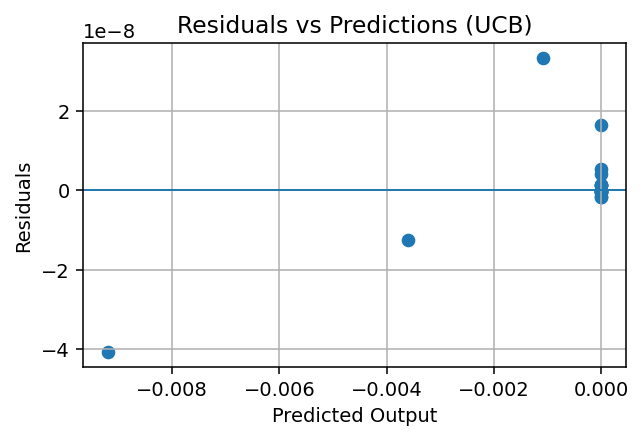

In [73]:
best_row_overall = log_df.loc[log_df['best_rmse_so_far'].idxmin()]

# Construct best_params from the space keys, which now includes max_depth and subsample
best_params = {k: float(best_row_overall[k]) for k in space.keys()}

# Ensure integer hyperparameters are cast correctly
best_params["n_estimators"] = int(best_params["n_estimators"])
best_params["max_depth"] = int(best_params["max_depth"])

print(f"Baseline GBR RMSE: {baseline_rmse:.3f}")
print("Optimized hyperparameters (from BO with UCB):")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"Achieved RMSE (UCB): {best_row_overall['best_rmse_so_far']:.5f}")

final = GradientBoostingRegressor(
    n_estimators=best_params["n_estimators"],
    learning_rate=best_params["learning_rate"],
    max_depth=best_params["max_depth"],
    subsample=best_params["subsample"],
    random_state=42
)
final_rmse = rmse_cv(final)
print("\nFinal (BO with UCB) 5-fold RMSE:", round(final_rmse, 3))

final.fit(X, y)
pred = final.predict(X)
resid = y - pred # Corrected: subtract predictions from actual target values (y)

plt.figure()
plt.scatter(pred, resid)
plt.axhline(0, linewidth=1)
plt.xlabel("Predicted Output"); plt.ylabel("Residuals") # Changed label for generality
plt.title("Residuals vs Predictions (UCB)")
plt.show()

Residuals plot shows a fairly scattered distribution around zero, which is a good sign for my model.

### Log review (each step)

In [58]:
try:
    import caas_jupyter_tools as cj
    subset_cols = ["iter","tag","rmse","best_rmse_so_far","mu","sigma","ei","exploit_contrib","explore_contrib"] + list(space.keys())
    log_view = log_df[subset_cols].round(4)
    cj.display_dataframe_to_user("BayesOpt_Step_Log", log_view)
except Exception:
    pass

log_df.head(20)

,iter,tag,rmse,best_rmse_so_far,mu,sigma,ei,exploit_contrib,explore_contrib,n_estimators,learning_rate,max_depth,subsample
0,-7,Warm-up,0.001749,0.001749,NaN,NaN,NaN,NaN,NaN,294.0,0.092980,3.0,0.775657
1,-6,Warm-up,0.001571,0.001571,NaN,NaN,NaN,NaN,NaN,302.0,0.132701,10.0,0.842415
2,-5,Warm-up,0.001480,0.001480,NaN,NaN,NaN,NaN,NaN,218.0,0.123714,4.0,0.864525
3,-4,Warm-up,0.001415,0.001415,NaN,NaN,NaN,NaN,NaN,204.0,0.027307,5.0,0.868998
4,-3,Warm-up,0.001769,0.001415,NaN,NaN,NaN,NaN,NaN,114.0,0.060881,6.0,0.765914
5,-2,Warm-up,0.001624,0.001415,NaN,NaN,NaN,NaN,NaN,272.0,0.256335,8.0,0.805512
6,-1,Warm-up,0.002002,0.001415,NaN,NaN,NaN,NaN,NaN,303.0,0.103658,4.0,0.614132
7,0,Warm-up,0.002049,0.001415,NaN,NaN,NaN,NaN,NaN,153.0,0.192983,2.0,0.716851
8,1,UCB (Exploitation),0.002010,0.001415,0.001791,0.000242,NaN,0.001791,0.001210,355.0,0.290323,1.0,0.501215
9,2,UCB (Exploitation),0.002584,0.001415,0.001892,0.000202,NaN,0.001892,0.001008,123.0,0.296030,9.0,0.507190


### Suggesting the Next X Data Point using Bayesian Optimization

To find the next best `x` (2D coordinates) to sample in the contamination field, we will set up a separate Bayesian Optimization process. This process will:

1.  **Fit a Gaussian Process Regressor** on the existing `X` (2D coordinates) and `y` (contamination readings).
2.  **Generate a grid of candidate points** across the 2D input space.
3.  **Evaluate an Acquisition Function** (like Upper Confidence Bound - UCB) for each candidate point.
4.  **Identify the candidate point** with the highest acquisition function value as the next suggested `x` for sampling.

Suggested next X data point (2D coordinates): [0.79964398 0.49863492]
Predicted Y at this point (mean): -7.71497e-04
Predicted uncertainty (std) at this point: 2.21241e-03
UCB value at this point: 2.20470e-01


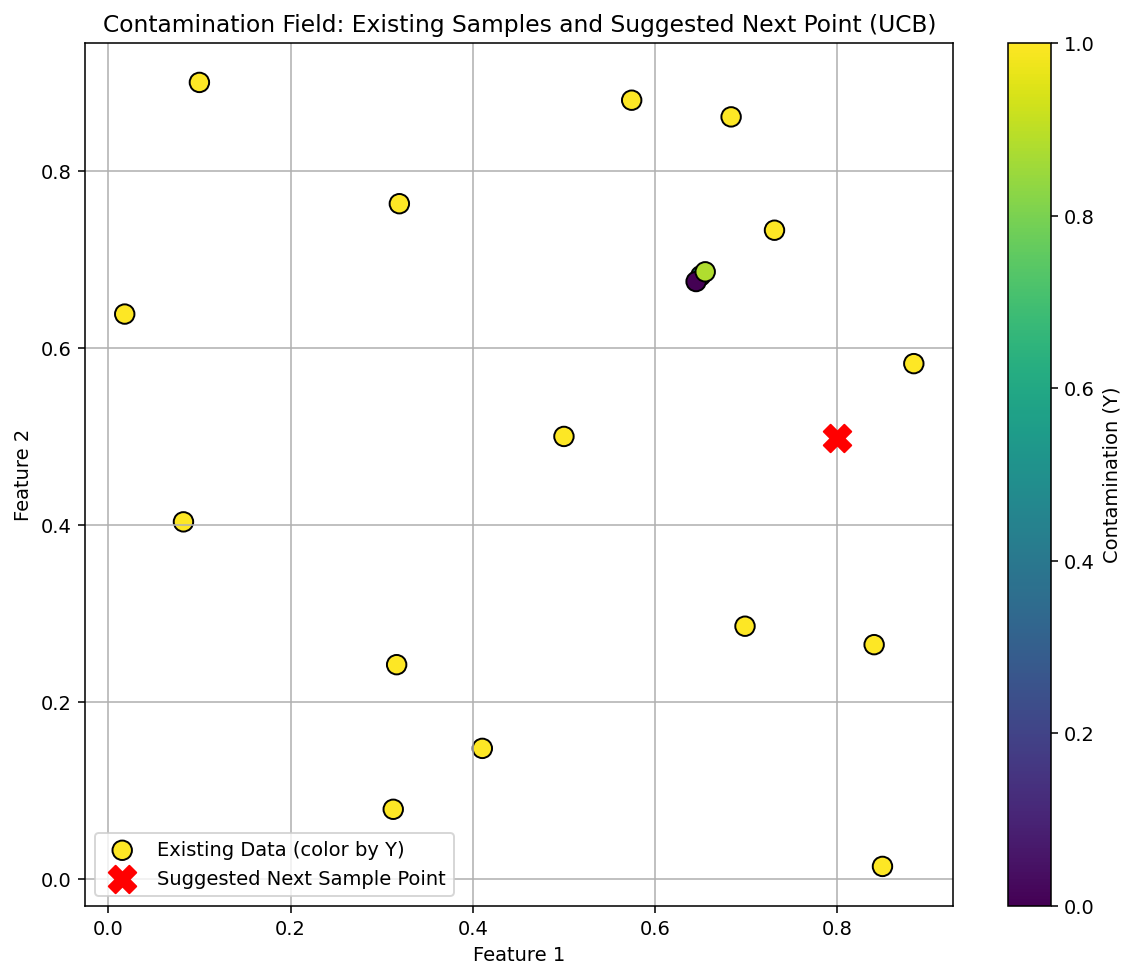

In [75]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the 2D search space for the contamination field
# Assuming X values are normalized or within a known range, e.g., [0, 1] for both features
x_space = [(0, 1), (0, 1)] # Define the bounds for each of the two X features

d_x = X.shape[1] # Dimension of the X input space (should be 2)

# 2. Initialize and fit a Gaussian Process Regressor on the contamination data
# We'll use the same kernel structure as for hyperparameter optimization, but applied to the X, y data
# Note: Normalizing y is crucial for GP performance
kernel_2d = C(1.0, (1e-3, 1e3)) * Matern(length_scale=np.ones(d_x), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-9, 1e-2))
gpr_2d = GaussianProcessRegressor(kernel=kernel_2d, normalize_y=True, random_state=42, n_restarts_optimizer=3)

gpr_2d.fit(X, y)

# 3. Generate a grid of candidate points across the 2D input space
n_candidates_2d = 10000 # Number of candidate points for the 2D search space

# Create a uniform grid of candidates within the defined x_space
# For simplicity, we'll generate random candidates within the bounds [0,1] for both features
# In a real scenario, you might want a more structured grid or Latin Hypercube Sampling
candidates_2d = np.random.rand(n_candidates_2d, d_x)

# 4. Predict mean and standard deviation for these candidates
mu_2d, std_2d = gpr_2d.predict(candidates_2d, return_std=True)

# 5. Compute the Upper Confidence Bound (UCB) acquisition function
# We need to decide on a KAPPA for this 2D search. A higher KAPPA means more exploration.
KAPPA_2D = KAPPA # You can adjust this value to control exploration vs. exploitation for the 2D space

# Since we are trying to MAXIMIZE contamination, UCB is calculated as mu + KAPPA * std
ucb_acquisition = mu_2d + KAPPA_2D * std_2d

# 6. Identify the candidate point with the maximum UCB
best_ucb_idx = np.argmax(ucb_acquisition)
next_x_data_point = candidates_2d[best_ucb_idx]
predicted_y_at_next_x = mu_2d[best_ucb_idx]
predicted_std_at_next_x = std_2d[best_ucb_idx]

print(f"Suggested next X data point (2D coordinates): {next_x_data_point}")
print(f"Predicted Y at this point (mean): {predicted_y_at_next_x:.5e}")
print(f"Predicted uncertainty (std) at this point: {predicted_std_at_next_x:.5e}")
print(f"UCB value at this point: {ucb_acquisition[best_ucb_idx]:.5e}")

# Visualize the results
plt.figure(figsize=(10, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=100, label='Existing Data (color by Y)', edgecolors='k')
plt.scatter(next_x_data_point[0], next_x_data_point[1], color='red', marker='X', s=200, label='Suggested Next Sample Point', zorder=5)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Contamination Field: Existing Samples and Suggested Next Point (UCB)')
plt.colorbar(label='Contamination (Y)')
plt.legend()
plt.grid(True)
plt.show()

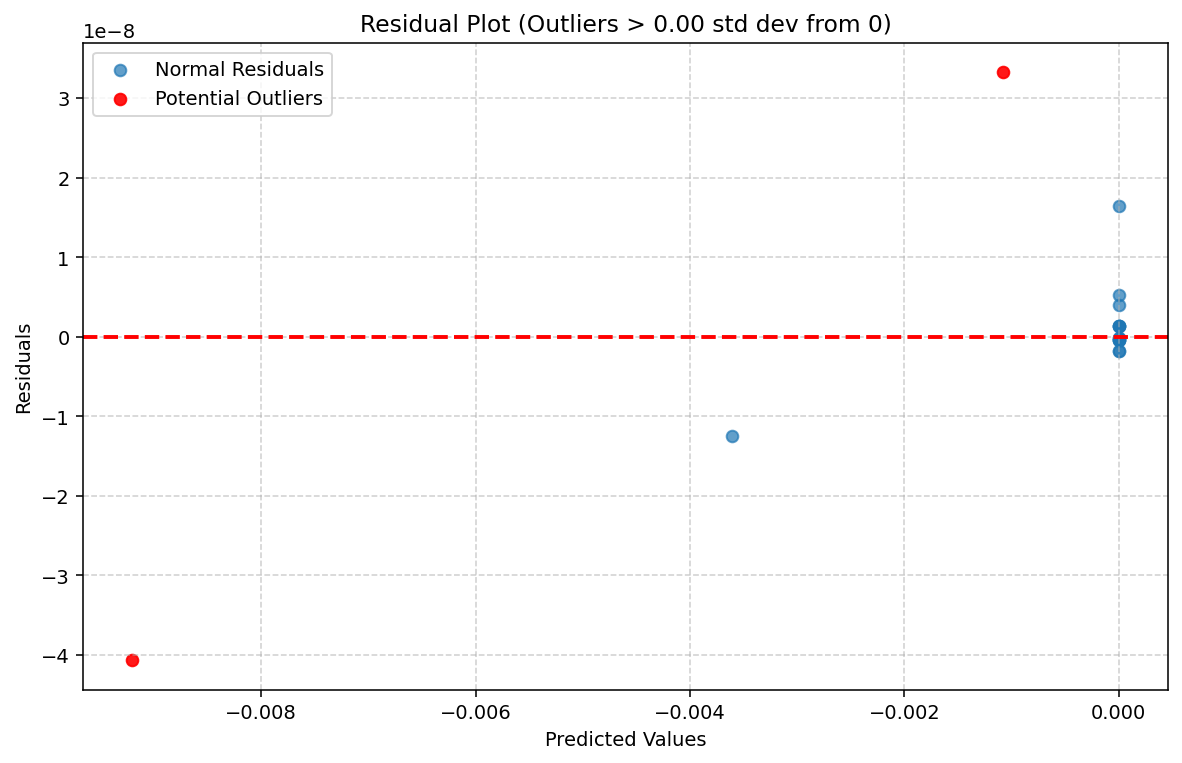


--- Outlier Data Points ---
Features (X):
[[0.645 0.675]
 [0.655 0.686]]

Actual Y values:
[-0.00920047 -0.00108042]

Predicted Y values:
[-0.00920043 -0.00108045]

Residuals:
[-4.06664474e-08  3.32589168e-08]


In [76]:
# Calculate predictions and residuals using the final model
pred = final.predict(X)
residuals = y - pred

# Identify potential outliers
# A common heuristic is to consider residuals beyond 2 or 3 standard deviations
residual_std = np.std(residuals)
outlier_threshold = 2 * residual_std # You can adjust this multiplier

# Create a boolean array to mark outliers
is_outlier = np.abs(residuals) > outlier_threshold

# Create the residual plot
plt.figure(figsize=(10, 6))

# Plot non-outliers in one color
plt.scatter(pred[~is_outlier], residuals[~is_outlier], alpha=0.7, label='Normal Residuals')

# Plot outliers in a different color
plt.scatter(pred[is_outlier], residuals[is_outlier], color='red', alpha=0.9, label='Potential Outliers')

plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title(f'Residual Plot (Outliers > {outlier_threshold:.2f} std dev from 0)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

print("\n--- Outlier Data Points ---")
if np.any(is_outlier):
    print("Features (X):")
    print(X[is_outlier])
    print("\nActual Y values:")
    print(y[is_outlier])
    print("\nPredicted Y values:")
    print(pred[is_outlier])
    print("\nResiduals:")
    print(residuals[is_outlier])
else:
    print("No outliers detected based on the current threshold.")

In [77]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# Define a function to calculate RMSE using cross-validation
def rmse_cv_lr(model, X, y, cv_splits=5):
    cv = KFold(n_splits=cv_splits, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=cv, scoring="neg_mean_squared_error")
    return float(np.sqrt(-scores).mean())

# Initialize and train the Linear Regression model
linear_model = LinearRegression()

# Calculate RMSE using cross-validation
linear_rmse = rmse_cv_lr(linear_model, X, y)

print(f"Linear Regression RMSE (5-fold): {linear_rmse:.3f}")

# Compare with baseline GBR and optimized GBR (from previous cells)
print(f"Baseline GBR RMSE: {baseline_rmse:.3f}")
print(f"Optimized GBR RMSE: {final_rmse:.3f}")

if linear_rmse < baseline_rmse:
    print("\nLinear Regression performed better than the Baseline GBR.")
else:
    print("\nLinear Regression performed worse than the Baseline GBR.")

if linear_rmse < final_rmse:
    print("Linear Regression performed better than the Optimized GBR.")
else:
    print("Linear Regression performed worse than the Optimized GBR.")


Linear Regression RMSE (5-fold): 0.002
Baseline GBR RMSE: 0.001
Optimized GBR RMSE: 0.001

Linear Regression performed worse than the Baseline GBR.
Linear Regression performed worse than the Optimized GBR.
